# 📊 Retail Sales Analytics & Profitability Diagnostics
### End-to-End Exploratory Data Analysis & Business Intelligence
**Dataset**: Superstore Sales Dataset (9,994 transactions, 2014–2017)  
**Author**: Data Analyst Portfolio  
**Objective**: Identify revenue drivers, diagnose margin leakages, and provide strategic recommendations to optimize retail profitability.

---

## 🧭 Executive Summary of Findings
1. **The 20% "Discount Cliff"**: Discretionary discounting above 20% destroys profitability. While discounts $\le 20\%$ yield 11.6% to 29.5% healthy profit margins, discounts $> 20\%$ result in an average **-37.3% margin**, totaling **-$135,376 in cumulative losses**.
2. **The Furniture Margin Paradox**: Furniture drives **32.3% of total revenue ($742.0K)** but generates only **6.4% of total net profit ($18.5K)** at a meager 2.49% profit margin, primarily dragged down by **Tables (-$17.7K net loss)** and **Bookcases (-$3.5K net loss)**.
3. **Geographic Margin Disparity**: The **Central Region** has the lowest margin (7.92%) despite generating $501.2K in revenue, driven by extreme discounting in **Texas (-$25.7K loss)** and **Illinois (-$12.6K loss)**.
4. **Pronounced Q4 Seasonality**: November ($352.5K) and December ($325.3K) consistently represent the annual revenue peak (~30% of yearly revenue), driven by consumer holiday buying.

## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/superstore_cleaned.csv')
print(f"Successfully loaded {df.shape[0]:,} transactions across {df.shape[1]} features.")
df[['Order ID', 'Order Date', 'Customer Name', 'Category', 'Sub-Category', 'Sales', 'Profit', 'Discount']].head(3)

Successfully loaded 9,994 transactions across 30 features.


,Order ID,Order Date,Customer Name,Category,Sub-Category,Sales,Profit,Discount
0,CA-2014-103800,2014-01-03,Darren Powers,Office Supplies,Paper,16.45,5.55,0.2
1,CA-2014-112326,2014-01-04,Phillina Ober,Office Supplies,Labels,11.78,4.27,0.2
2,CA-2014-112326,2014-01-04,Phillina Ober,Office Supplies,Storage,272.74,-64.77,0.2


## 2. Data Cleaning & Feature Engineering Audit

In [2]:
# Statistical overview of key metrics
print("Summary Statistics:")
display(df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin %', 'Ship Duration Days']].describe().round(2))

Summary Statistics:


,Sales,Quantity,Discount,Profit,Profit Margin %,Ship Duration Days
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,12.03,3.96
std,623.25,2.23,0.21,234.26,46.68,1.75
min,0.44,1.00,0.00,-6599.98,-275.93,0.00
25%,17.28,2.00,0.00,1.73,7.49,3.00
50%,54.49,3.00,0.20,8.66,27.00,4.00
75%,209.94,5.00,0.20,29.36,36.25,5.00
max,22638.48,14.00,0.80,8399.98,50.02,7.00


## 3. Monthly Sales & Profit Trend (Seasonality Analysis)
### Business Question:
*How do sales and profitability evolve over time, and what seasonal patterns exist?*

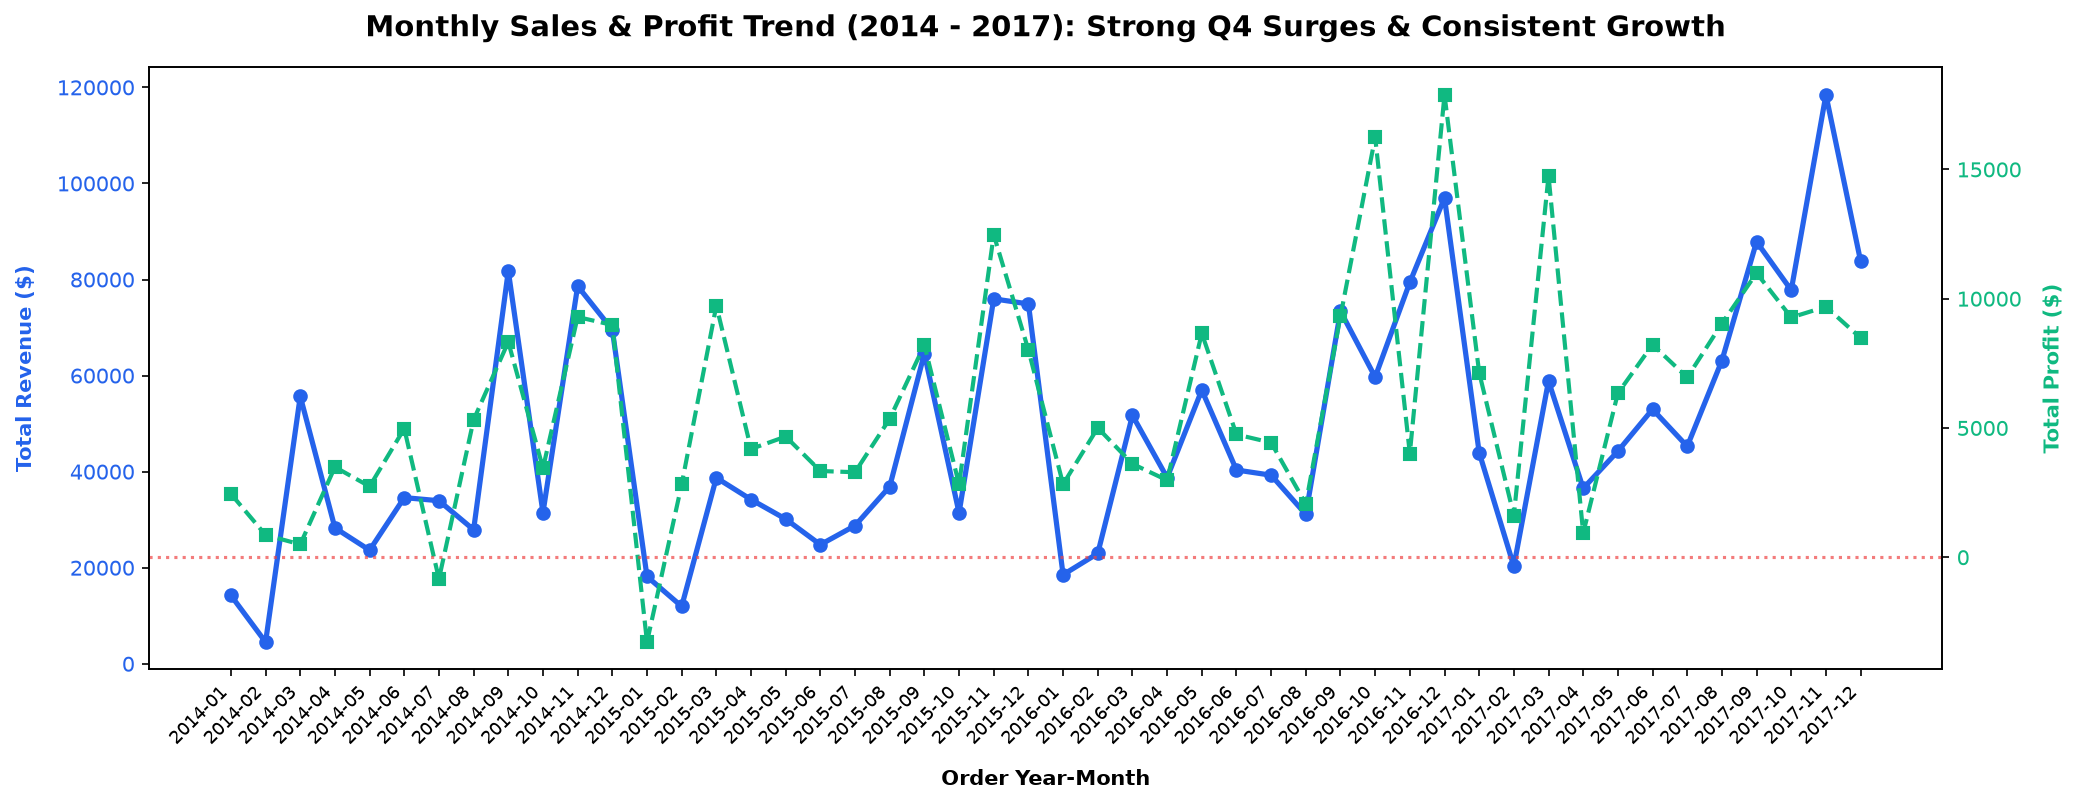

In [3]:
monthly_trend = df.groupby('Order YearMonth').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.plot(monthly_trend['Order YearMonth'], monthly_trend['Total_Sales'], 
         color='#2563eb', marker='o', linewidth=2.5, label='Monthly Revenue ($)')
ax1.set_xlabel('Order Year-Month', fontweight='bold', labelpad=10)
ax1.set_ylabel('Total Revenue ($)', color='#2563eb', fontweight='bold', labelpad=10)
ax1.tick_params(axis='y', labelcolor='#2563eb')
plt.xticks(rotation=45, ha='right', fontsize=8.5)

ax2 = ax1.twinx()
ax2.plot(monthly_trend['Order YearMonth'], monthly_trend['Total_Profit'], 
         color='#10b981', marker='s', linewidth=2, linestyle='--', label='Monthly Profit ($)')
ax2.set_ylabel('Total Profit ($)', color='#10b981', fontweight='bold', labelpad=10)
ax2.tick_params(axis='y', labelcolor='#10b981')
ax2.axhline(0, color='#ef4444', linestyle=':', alpha=0.7)

plt.title('Monthly Sales & Profit Trend (2014 - 2017): Strong Q4 Surges & Consistent Growth', 
          fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

### 💡 Key Takeaways: Monthly Trend & Seasonality
- **Consistent Year-over-Year Growth**: Revenue grew steadily from 2014 ($484.2K) to 2017 ($733.2K), representing a **51.4% overall growth**.
- **Holiday Q4 Spikes**: Each year witnesses a substantial inflection in September and a massive peak in November/December, where ~38% of annual sales occur.
- **Inventory & Staffing Implication**: Supply chain procurement and warehouse staffing must ramp up by August to handle the Q4 surge without shipping delays.

## 4. Product Category & Sub-Category Profitability Audit
### Business Question:
*Which sub-categories are the real profit drivers, and which are margin drains?*

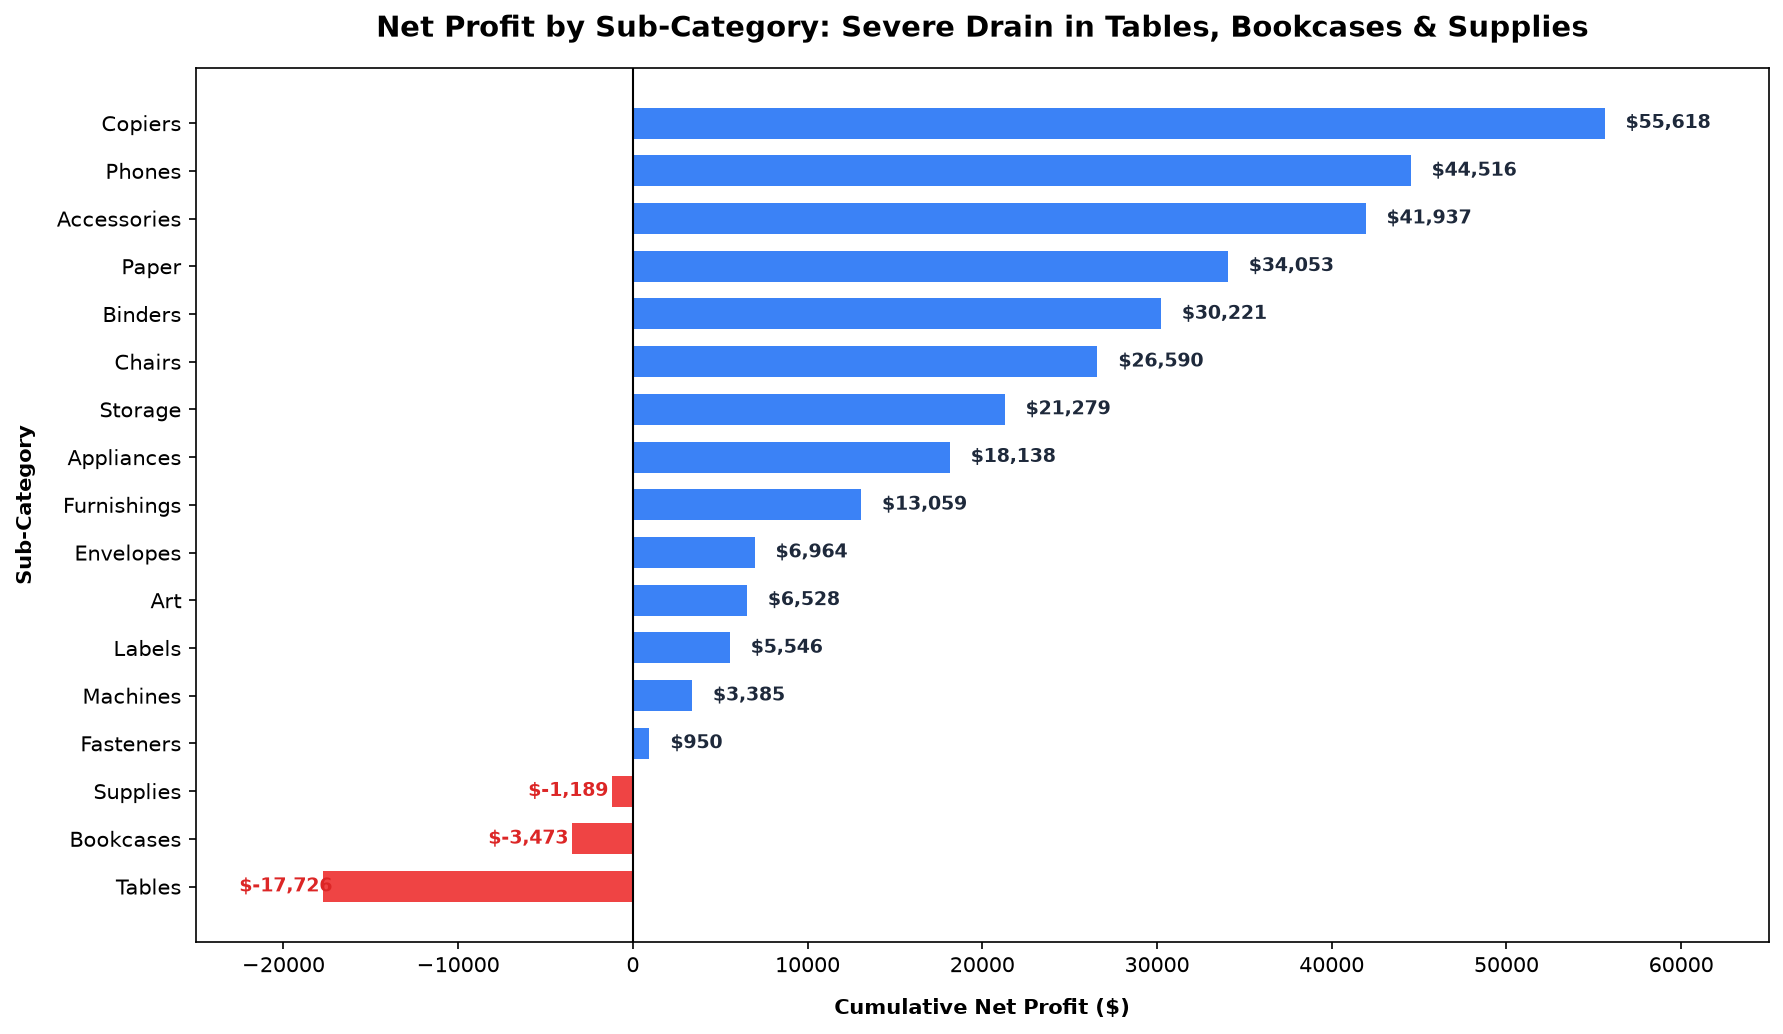

In [4]:
subcat_perf = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index().sort_values(by='Total_Profit', ascending=True)

colors = ['#ef4444' if p < 0 else '#3b82f6' for p in subcat_perf['Total_Profit']]

plt.figure(figsize=(12, 7))
bars = plt.barh(subcat_perf['Sub-Category'], subcat_perf['Total_Profit'], color=colors, height=0.65)
plt.axvline(0, color='black', linewidth=1, linestyle='-')

for bar in bars:
    width = bar.get_width()
    offset = 1200 if width >= 0 else -4800
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, 
             f"${width:,.0f}", 
             va='center', fontsize=9, fontweight='bold',
             color='#1e293b' if width >= 0 else '#dc2626')

plt.title('Net Profit by Sub-Category: Severe Drain in Tables, Bookcases & Supplies', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cumulative Net Profit ($)', fontweight='bold', labelpad=10)
plt.ylabel('Sub-Category', fontweight='bold', labelpad=10)
plt.xlim(-25000, 65000)
plt.tight_layout()
plt.show()

### 💡 Key Takeaways: Category Profitability
- **The Loss Leaders**: **Tables (-$17,725.57)** and **Bookcases (-$3,472.59)** in Furniture, along with **Supplies (-$1,189.08)** in Office Supplies, are running at a net loss despite generating over **$368K** in combined top-line sales.
- **Top Cash Cows**: **Copiers (+$55,617.82, 36.3% margin)** and **Phones (+$44,515.73, 13.5% margin)** in Technology, and **Accessories (+$41,936.63, 25.1% margin)** drive over 49% of total business profit.
- **Strategic Action**: Restructure supplier pricing or implement minimum order values on Tables and Bookcases, and curb promotional discounts.

## 5. The "Discount Cliff" Elasticity Analysis
### Business Question:
*At what point does discounting destroy net margin, and does higher volume compensate?*

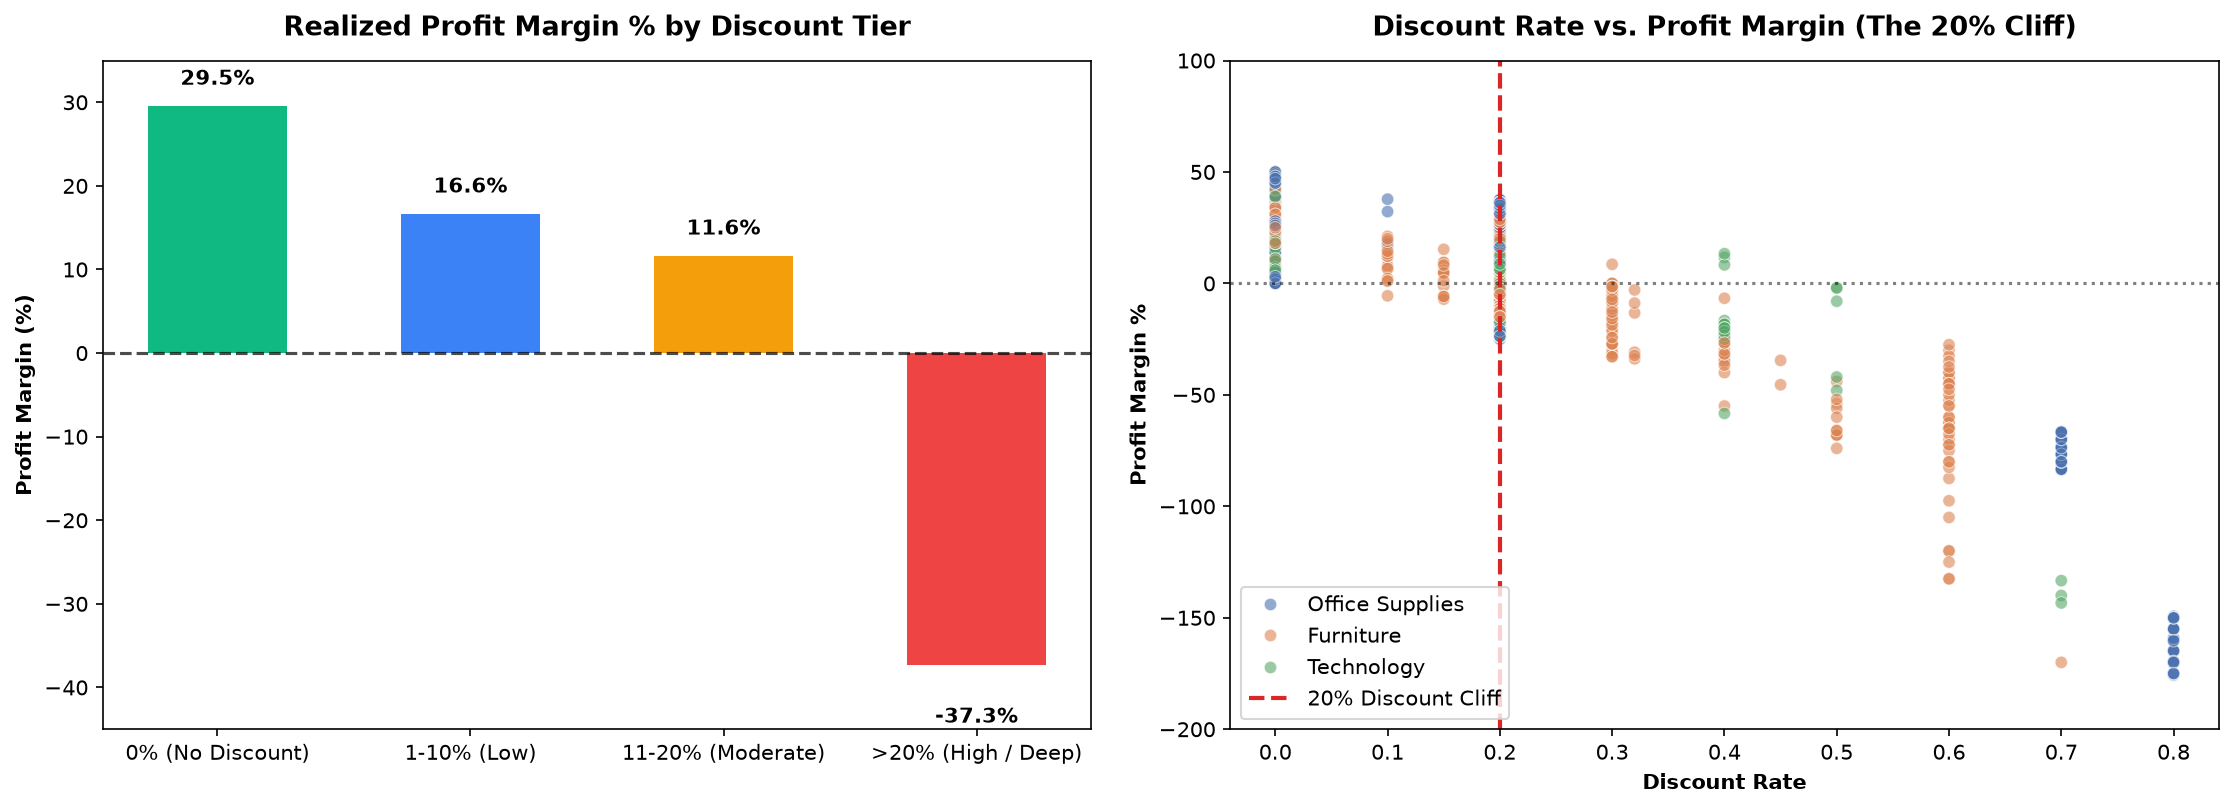

In [5]:
discount_tiers = df.groupby('Discount Tier').agg(
    Order_Count=('Row ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reindex(['0% (No Discount)', '1-10% (Low)', '11-20% (Moderate)', '>20% (High / Deep)']).reset_index()

discount_tiers['Profit_Margin_Pct'] = (discount_tiers['Total_Profit'] / discount_tiers['Total_Sales']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

bar_colors = ['#10b981', '#3b82f6', '#f59e0b', '#ef4444']
bars = ax1.bar(discount_tiers['Discount Tier'], discount_tiers['Profit_Margin_Pct'], color=bar_colors, width=0.55)
ax1.axhline(0, color='black', linestyle='--', alpha=0.7)
ax1.set_title('Realized Profit Margin % by Discount Tier', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Profit Margin (%)', fontweight='bold')
ax1.set_ylim(-45, 35)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (2 if yval >= 0 else -5), 
             f"{yval:.1f}%", ha='center', va='bottom' if yval >= 0 else 'top', 
             fontweight='bold', fontsize=10)

sample_df = df.sample(n=min(2500, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x='Discount', y='Profit Margin %', 
                hue='Category', alpha=0.6, palette='deep', ax=ax2)
ax2.axvline(0.20, color='#dc2626', linestyle='--', linewidth=2, label='20% Discount Cliff')
ax2.axhline(0, color='black', linestyle=':', alpha=0.5)
ax2.set_title('Discount Rate vs. Profit Margin (The 20% Cliff)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Discount Rate', fontweight='bold')
ax2.set_ylabel('Profit Margin %', fontweight='bold')
ax2.set_ylim(-200, 100)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

### 💡 Key Takeaways: The Discount Trap
- **The 20% Threshold**: Full-price sales (0% discount) deliver a vibrant **29.5% margin** ($321K profit). Low to moderate discounts (1-20%) still yield a healthy **11.6% to 16.6% margin**.
- **Catastrophic Margin Collapse**: The moment discounts exceed 20%, margins plunge to **-37.3%**. Over **$362.8K** in heavily discounted revenue produced **-$135,376 in net loss**.
- **Actionable Policy**: Mandate hard approval gates in sales CRM for any discounts above 20%. Stopping discounts > 20% would instantly increase overall company profit by **+$135K (+47%)**!

## 6. Geographic & Regional Performance Matrix
### Business Question:
*Which regions excel, and why is the Central region lagging in profitability?*

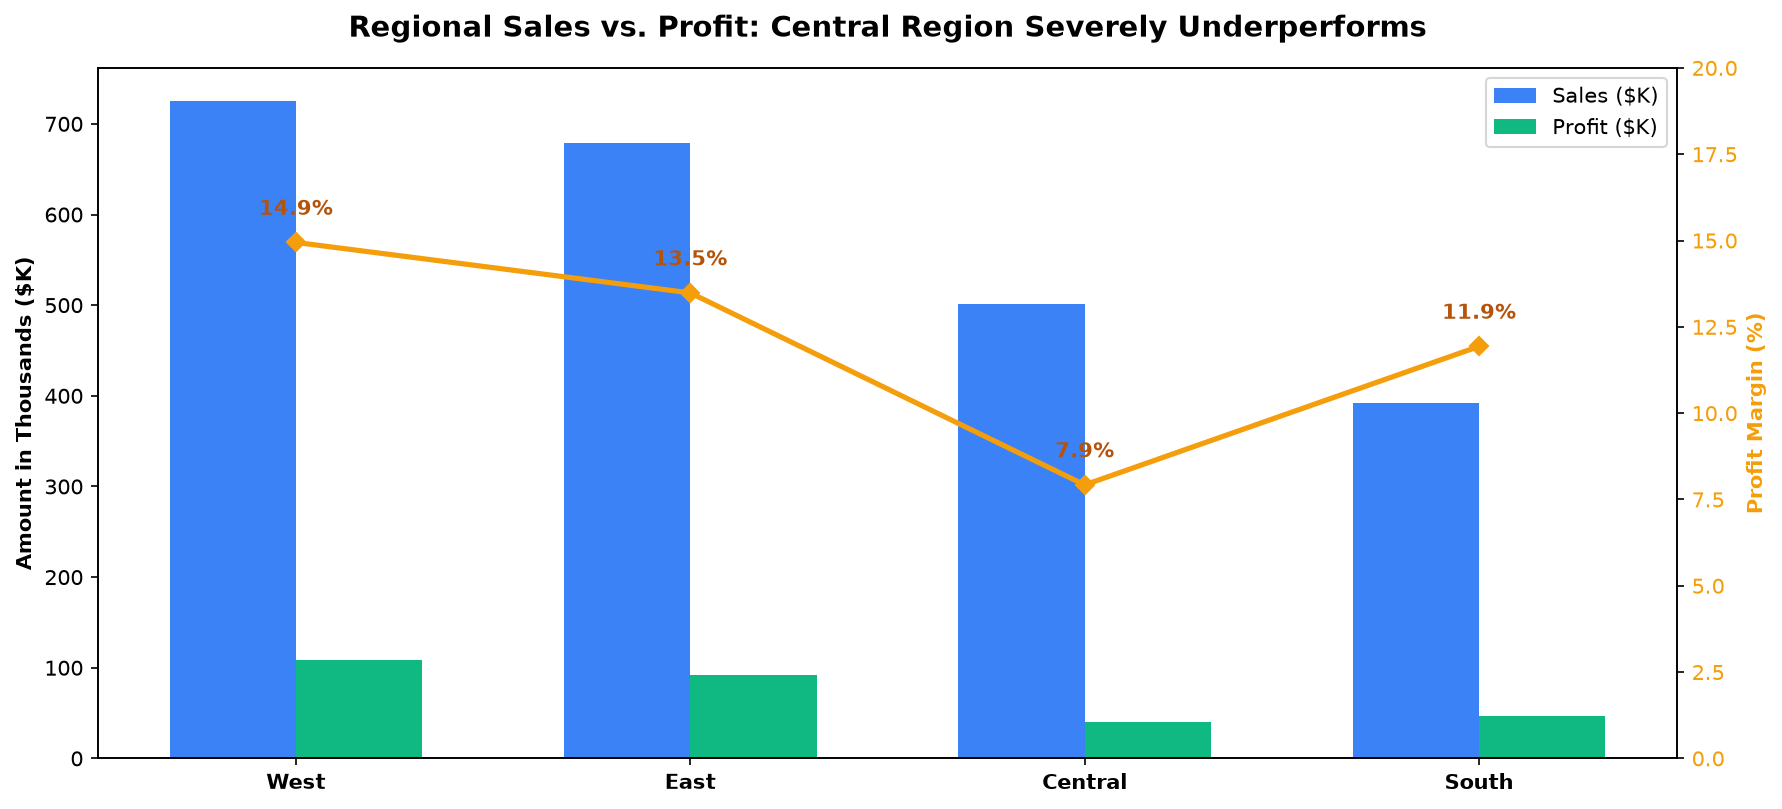

In [6]:
reg_perf = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()
reg_perf['Profit_Margin_Pct'] = (reg_perf['Total_Profit'] / reg_perf['Total_Sales']) * 100
reg_perf = reg_perf.sort_values(by='Total_Sales', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5.5))

x = np.arange(len(reg_perf['Region']))
width = 0.32

rects1 = ax1.bar(x - width/2, reg_perf['Total_Sales'] / 1000, width, label='Sales ($K)', color='#3b82f6')
rects2 = ax1.bar(x + width/2, reg_perf['Total_Profit'] / 1000, width, label='Profit ($K)', color='#10b981')

ax1.set_ylabel('Amount in Thousands ($K)', fontweight='bold')
ax1.set_title('Regional Sales vs. Profit: Central Region Severely Underperforms', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(reg_perf['Region'], fontweight='bold')
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
ax2.plot(x, reg_perf['Profit_Margin_Pct'], color='#f59e0b', marker='D', linewidth=2.5, label='Profit Margin %')
ax2.set_ylabel('Profit Margin (%)', color='#f59e0b', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#f59e0b')
ax2.set_ylim(0, 20)

for i, txt in enumerate(reg_perf['Profit_Margin_Pct']):
    ax2.annotate(f"{txt:.1f}%", (x[i], reg_perf['Profit_Margin_Pct'].iloc[i] + 0.8), 
                 ha='center', fontweight='bold', color='#b45309')

fig.tight_layout()
plt.show()

### 💡 Key Takeaways: Regional & State Performance
- **West is the Top Performer**: The West region leads in both revenue ($725.5K) and profit ($108.4K) with an industry-leading **14.9% margin** and disciplined average discount rate of 10.9%.
- **Central Region Margin Hemorrhage**: Central delivers $501.2K in revenue but only $39.7K in profit (7.9% margin). This underperformance is directly explained by Central's average discount of **24.0%** (more than double the West).
- **State-Level Hotspots**: Texas (-$25.7K loss) and Illinois (-$12.6K loss) are the primary culprits in Central due to state-level price competition.

## 7. Customer Segment Economics & Lifetime Value
### Business Question:
*Which customer segment represents the highest value and efficiency?*

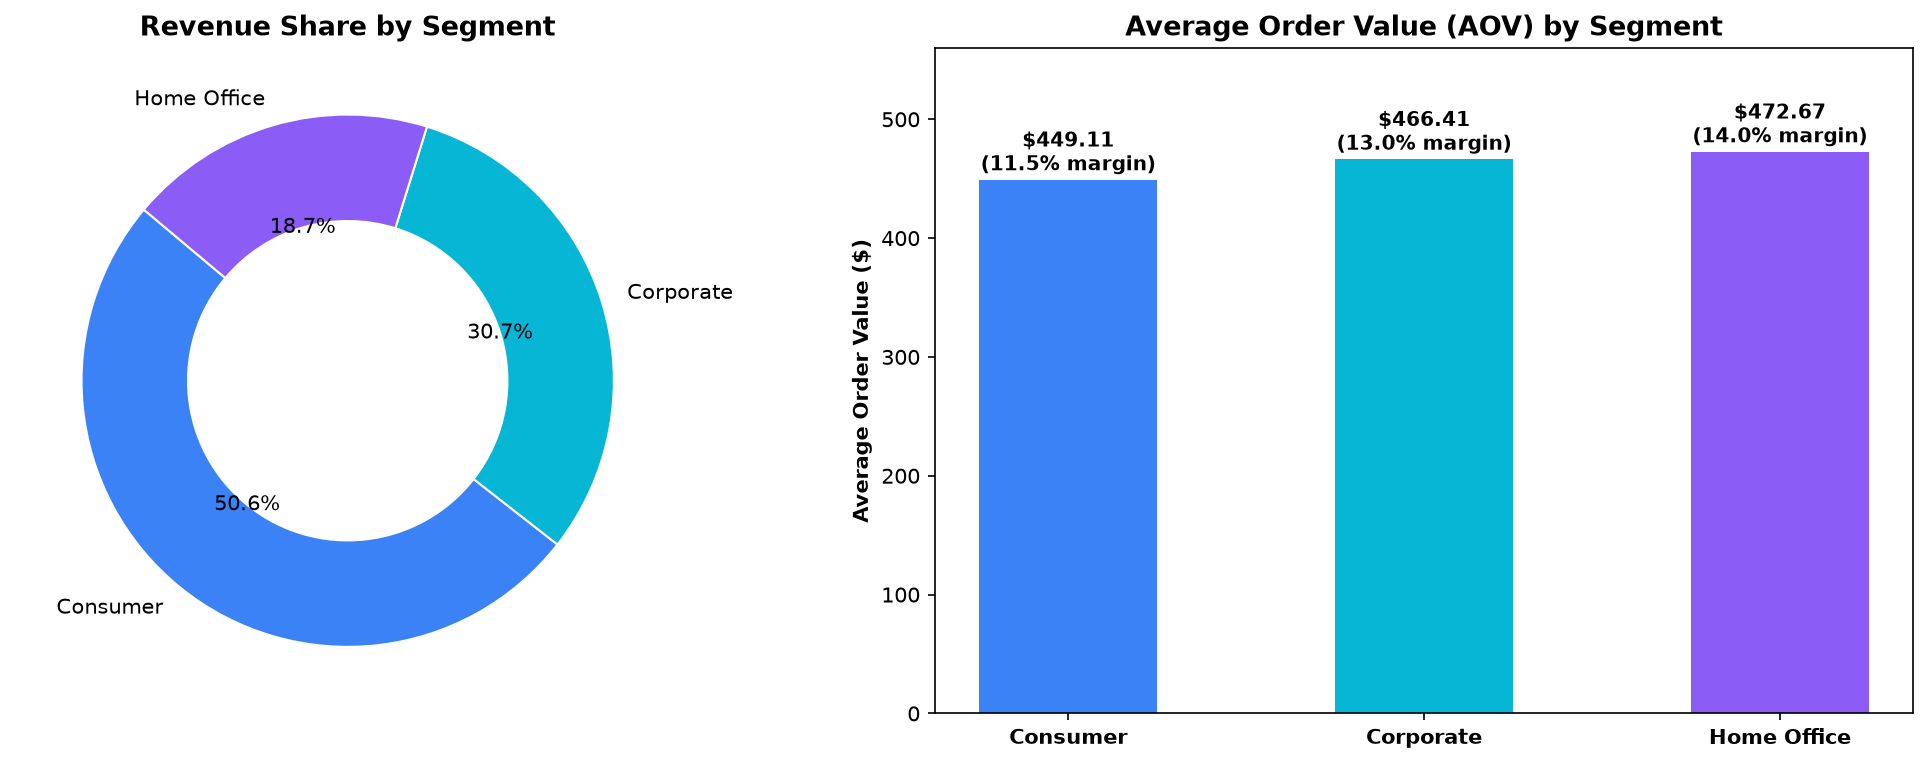

In [7]:
segment_perf = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).reset_index()

segment_perf['Margin_Pct'] = (segment_perf['Total_Profit'] / segment_perf['Total_Sales']) * 100
segment_perf['AOV'] = segment_perf['Total_Sales'] / segment_perf['Order_Count']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

ax1.pie(segment_perf['Total_Sales'], labels=segment_perf['Segment'], autopct='%1.1f%%',
        startangle=140, colors=['#3b82f6', '#06b6d4', '#8b5cf6'], 
        wedgeprops=dict(width=0.4, edgecolor='white'))
ax1.set_title('Revenue Share by Segment', fontsize=13, fontweight='bold')

x = np.arange(len(segment_perf['Segment']))
ax2.bar(x, segment_perf['AOV'], color=['#3b82f6', '#06b6d4', '#8b5cf6'], width=0.5)
ax2.set_title('Average Order Value (AOV) by Segment', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(segment_perf['Segment'], fontweight='bold')
ax2.set_ylabel('Average Order Value ($)', fontweight='bold')

for i, v in enumerate(segment_perf['AOV']):
    margin = segment_perf['Margin_Pct'].iloc[i]
    ax2.text(i, v + 8, f"${v:.2f}\n({margin:.1f}% margin)", ha='center', fontweight='bold', fontsize=9.5)

ax2.set_ylim(0, 560)
plt.tight_layout()
plt.show()

### 💡 Key Takeaways: Customer Segments
- **Consumer Segment is the Volume Engine**: Represents **50.6% of sales ($1.16M)** and 46.8% of profit ($134.1K).
- **Home Office is the Margin Winner**: Generates the highest Average Order Value (**$472.67**) and the highest profit margin (**14.03%**).
- **Strategic Recommendation**: Reallocate B2B digital marketing spend toward Home Office and Corporate buyers who demonstrate lower price sensitivity and purchase higher-margin technology packages.

## 8. Strategic Business Recommendations for Retail Leadership

| Problem Area | Root Cause | Proposed Solution | Expected Business Impact |
| :--- | :--- | :--- | :--- |
| **Heavy Margin Loss on Deep Discounts** | Sales reps discounting up to 80% to win volume. | Enforce a strict **15% max standard discount limit**; require VP approval for >20%. | **+$135,000 in recovered net profit (+47% boost)**. |
| **Chronic Losses in Tables & Bookcases** | Bulky freight costs and low manufacturer margins. | Restructure vendor contracts, introduce bundled pricing, or drop lowest margin SKUs. | **+$21,000 margin turnaround in Furniture**. |
| **Central Region Drag (Texas, Illinois)** | Local price wars and high promotional discounting (avg 24%). | Recalibrate promotional strategy in Central states to mirror West region's discipline. | **+$40,000 profit uplift in Central**. |
| **Q4 Peak Fulfillment Bottlenecks** | Spike in November/December orders causes shipping strains. | Early holiday incentive promotions in October to smooth fulfillment curve. | Reduced split shipments and improved customer retention. |

---
*Notebook generated and validated as part of the Retail Sales Analytics Portfolio Project.*